In [1]:
# Sekcja 1: Import bibliotek
import pandas as pd # tabele danych
import matplotlib.pyplot as plt # wykresy
import seaborn as sns # źródło danych
from sklearn.model_selection import train_test_split # podzielenie danych na treningowe i testowe
import numpy as np # obliczenia na wielu liczbach na raz
import math # funckje matematyczne jednoliczbowe

In [2]:
# Sekcja 2: Wczytanie i zapoznanie się z danymi

# Źródło danych:
# https://github.com/mwaskom/seaborn-data/blob/master/iris.csv

dane = sns.load_dataset("iris")

# Pierwsze 10 rekordów
print("\nPierwsze 10 rekordów:")
print(dane.head(10))



Pierwsze 10 rekordów:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa


| Kolumna | Znaczenie |
|---|---|
| `sepal_length` | Długość działki kielicha kwiatu podana w centymetrach |
| `sepal_width` | Szerokość działki kielicha kwiatu podana w centymetrach |
| `petal_length` | Długość płatka kwiatu podana w centymetrach |
| `petal_width` | Szerokość płatka kwiatu podana w centymetrach |
| `species` | Gatunek kwiatu: `setosa`, `versicolor` lub `virginica` |

In [3]:
# *kontynuacja*

# Podstawowe informacje
cechy = dane.columns.drop("species")
gatunki = dane["species"].unique()

print("\nOpis zbioru danych Iris:")
print("Liczba próbek:", dane.shape[0])
print("Liczba cech:", len(cechy))
print("Cechy:", list(cechy))
print("Gatunki:", list(gatunki))

# Liczba kwiatów każdego gatunku
print("\nRozkład gatunków:")
print(dane["species"].value_counts())


Opis zbioru danych Iris:
Liczba próbek: 150
Liczba cech: 4
Cechy: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Gatunki: ['setosa', 'versicolor', 'virginica']

Rozkład gatunków:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
# Sekcja 3: Generowanie wykresów

# Pary cech, które będą ze sobą porównywane
feature_pairs = [
    # oś X              oś Y
    ("sepal_length", "sepal_width"),
    ("sepal_length", "petal_length"),
    ("sepal_length", "petal_width"),
    ("sepal_width", "petal_length"),
    ("sepal_width", "petal_width"),
    ("petal_length", "petal_width")
]

# Polskie nazwy cech
feature_names_pl = {
    "sepal_length": "Długość działki kielicha [cm]",
    "sepal_width": "Szerokość działki kielicha [cm]",
    "petal_length": "Długość płatka [cm]",
    "petal_width": "Szerokość płatka [cm]"
}



# **Po co analizujemy wszystkie pary?**

Na wykresach chcemy zobaczyć:

- czy dwie cechy są ze sobą powiązane,
- czy wraz ze wzrostem jednej cechy rośnie druga,
- które cechy najlepiej rozdzielają trzy gatunki,
- które pomiary mogą być najbardziej użyteczne dla modelu klasyfikacji.

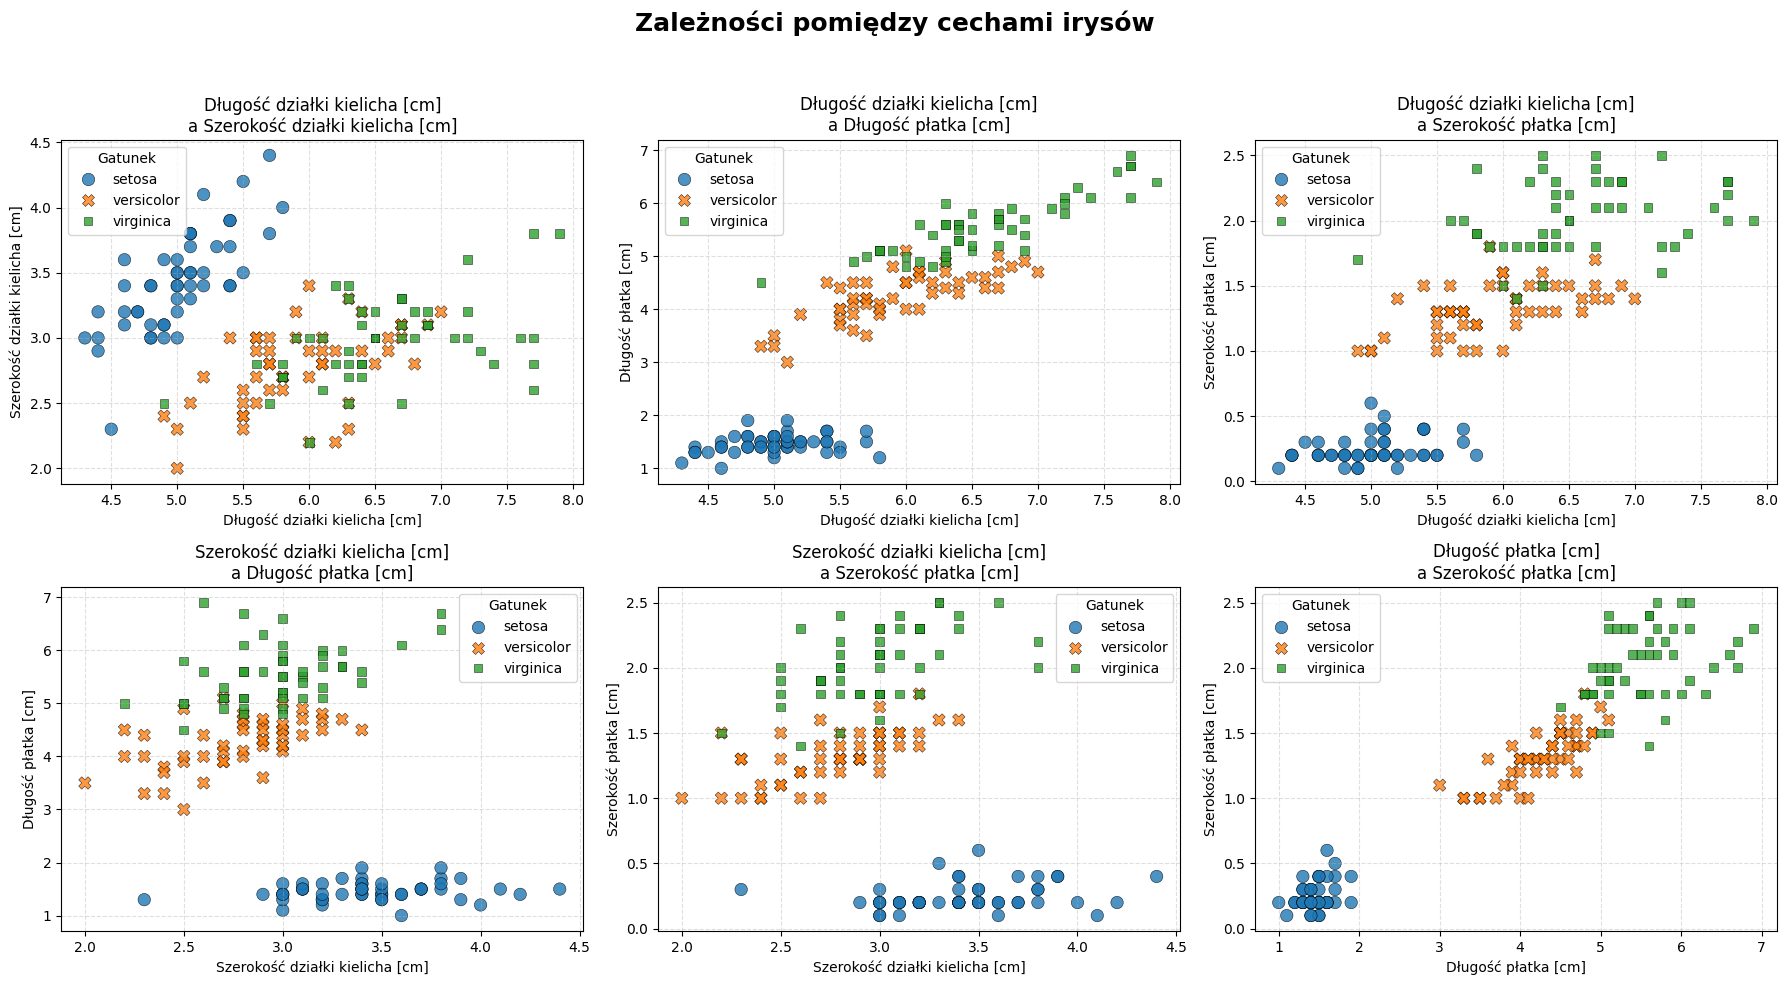

In [5]:
# *Kontynuacja*

# Utworzenie jednej figury zawierającej 6 wykresów
fig, osie = plt.subplots(2, 3, figsize=(18, 10))

# [wykres 1] [wykres 2] [wykres 3]
# [wykres 4] [wykres 5] [wykres 6]


# Tworzenie wykresów dla kolejnych par cech
for wykres, (cecha_x, cecha_y) in zip(osie.flat, feature_pairs):

    sns.scatterplot(
        data=dane,
        x=cecha_x,
        y=cecha_y,
        hue="species", # różne kolory dla każdego gatunku
        style="species", # różne oznaczenia dla każdego gatunku
        s=80, # rozmiar punktów
        alpha=0.8, # przezroczystosć
        edgecolor="black", # bwódka punktów
        linewidth=0.4, # grubosć obwódki
        ax=wykres # miejsce rysowania
    )

    # Tytuł wykresu
    wykres.set_title(
        f"{feature_names_pl[cecha_x]}\na {feature_names_pl[cecha_y]}",
        fontsize=12
    )

    # Opisy osi
    wykres.set_xlabel(feature_names_pl[cecha_x])
    wykres.set_ylabel(feature_names_pl[cecha_y])

    # Legenda i siatka
    wykres.legend(title="Gatunek")
    wykres.grid(linestyle="--", alpha=0.4)

# Tytuł całej figury
fig.suptitle(
    "Zależności pomiędzy cechami irysów",
    fontsize=18,
    fontweight="bold"
)

# Poprawienie odstępów między wykresami
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

---
# **ALGORYTM KNN**

*knn_iris_symulacja_euklidesowa.html*

---

**PSEUDOKOD:**

```
Funkcja KNN(nowy_kwiat, dane_uczące, k):

    Dla każdego kwiatu w danych uczących:
       - Oblicz odległość euklidesową od nowego kwiatu
       - Zapisz odległość razem z gatunkiem

    Posortuj kwiaty od najbliższego do najdalszego

    Wybierz k najbliższych kwiatów

    Policz, ile razy występuje każdy gatunek

    Wybierz gatunek z największą liczbą głosów

    Zwróć przewidywany gatunek
```


In [6]:
# Sekcja 4: Przygotowanie danych dla algorytmu

# Cechy, na podstawie których model będzie rozpoznawał gatunek
X = dane.drop(columns="species")

# Etykiety, czyli poprawne gatunki kwiatów
y = dane["species"]

# Podział danych na zbiór uczący i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True, # dane przestasowane przed podziałem
    stratify=y # zachowanie tych samych proporcji gatunków
)

# Informacje o podziale danych
print("\nPodział danych:")

print(
    f"Zbiór uczący: {len(X_train)} próbek "
    f"({len(X_train) / len(dane) * 100:.0f}%)"
)

print(
    f"Zbiór testowy: {len(X_test)} próbek "
    f"({len(X_test) / len(dane) * 100:.0f}%)"
)

# Rozkład gatunków w zbiorze uczącym
print("\nGatunki w zbiorze uczącym:")

for gatunek, liczba in y_train.value_counts().sort_index().items():
    print(f"{gatunek}: {liczba} próbek")

# Rozkład gatunków w zbiorze testowym
print("\nGatunki w zbiorze testowym:")

for gatunek, liczba in y_test.value_counts().sort_index().items():
    print(f"{gatunek}: {liczba} próbek")


Podział danych:
Zbiór uczący: 120 próbek (80%)
Zbiór testowy: 30 próbek (20%)

Gatunki w zbiorze uczącym:
setosa: 40 próbek
versicolor: 40 próbek
virginica: 40 próbek

Gatunki w zbiorze testowym:
setosa: 10 próbek
versicolor: 10 próbek
virginica: 10 próbek


In [7]:
# Sekcja 5: Implementacja algorytmu KNN


# Obliczenie odległości euklidesowej między dwoma kwiatami
def calculate_distance(point1, point2):
    distance = 0

    for value1, value2 in zip(point1, point2):
        distance += (value1 - value2) ** 2

    return np.sqrt(distance)


# Klasyfikowanie kwiatów ze zbioru testowego
def knn_classifier(X_train, y_train, X_test, k):

    # Zamiana danych Pandas na tablice NumPy
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)
    X_test = np.asarray(X_test)

    predictions = []

    # Klasyfikowanie kolejnych kwiatów testowych
    for test_point in X_test:

        distances = []

        # Obliczenie odległości od wszystkich kwiatów uczących
        for train_point, label in zip(X_train, y_train):

            distance = calculate_distance(test_point, train_point)

            # Zapisanie odległości razem z gatunkiem
            distances.append((distance, label))

        # Sortowanie od najmniejszej odległości
        distances.sort(key=lambda element: element[0])

        # Wybranie k najbliższych sąsiadów
        neighbors = distances[:k]

        # Zliczenie głosów poszczególnych gatunków
        votes = {}

        for _, label in neighbors:
            votes[label] = votes.get(label, 0) + 1

        # Wybranie gatunku z największą liczbą głosów
        most_common_label = max(votes, key=votes.get)

        # Zapisanie przewidywanego gatunku
        predictions.append(most_common_label)

    return predictions

In [10]:
# Sekcja 6: Testowanie algorytmu KNN

def test_KNN(k):
    predictions = knn_classifier(X_train, y_train, X_test, k)

    predictions = np.array(predictions)
    actual = np.array(y_test)

    print(f"\nWyniki dla k = {k}:")

    for i, (prediction, real) in enumerate(zip(predictions, actual), start=1):
        print(f"Próbka {i}: predykcja = {prediction}, rzeczywisty = {real}")

    accuracy = np.mean(predictions == actual)

    print(f"\nDokładność algorytmu KNN dla k = {k}: {accuracy:.2f}")

In [11]:
test_KNN(2)
test_KNN(3)
test_KNN(15)
test_KNN(28)
test_KNN(79)


Wyniki dla k = 2:
Próbka 1: predykcja = setosa, rzeczywisty = setosa
Próbka 2: predykcja = virginica, rzeczywisty = virginica
Próbka 3: predykcja = versicolor, rzeczywisty = versicolor
Próbka 4: predykcja = versicolor, rzeczywisty = versicolor
Próbka 5: predykcja = setosa, rzeczywisty = setosa
Próbka 6: predykcja = versicolor, rzeczywisty = versicolor
Próbka 7: predykcja = setosa, rzeczywisty = setosa
Próbka 8: predykcja = setosa, rzeczywisty = setosa
Próbka 9: predykcja = virginica, rzeczywisty = virginica
Próbka 10: predykcja = versicolor, rzeczywisty = versicolor
Próbka 11: predykcja = virginica, rzeczywisty = virginica
Próbka 12: predykcja = virginica, rzeczywisty = virginica
Próbka 13: predykcja = virginica, rzeczywisty = virginica
Próbka 14: predykcja = versicolor, rzeczywisty = versicolor
Próbka 15: predykcja = setosa, rzeczywisty = setosa
Próbka 16: predykcja = setosa, rzeczywisty = setosa
Próbka 17: predykcja = setosa, rzeczywisty = setosa
Próbka 18: predykcja = versicolor, r